* Simple Distance-Based Prediction
* Dataset: from sklearn.datasets import load_wine
* Task: Load a dataset like the Wine Quality dataset.
*
* Action: Implement a KNN classifier with . Train the model, make predictions on a hold-out test set, and evaluate the accuracy


In [3]:
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scale = StandardScaler()
X_scaled_train = scale.fit_transform(X_train)
X_scaled_test = scale.transform(X_test)

knn_model = KNeighborsClassifier()
knn_model.fit(X_scaled_train, y_train)

prediction = knn_model.predict(X_scaled_test)
accuracy = accuracy_score(y_test, prediction) 
print(accuracy)

0.9444444444444444


Hyperparameter Tuning (Finding the best 'k')
* Dataset: from sklearn.datasets import load_wine
* Task: The choice of drastically changes KNN's performance.
* Action: Write a loop or use GridSearchCV to train a KNN model with values ranging from 1 to 30. Record the training accuracy and validation accuracy for each . Plot these accuracies on a line graph to visually identify the "sweet spot" where the model neither overfits nor underfits.


    Train Accuracies  Value Accuracies
0           1.000000          1.000000
1           0.971831          0.971831
2           0.957746          0.957746
3           0.971831          0.971831
4           0.985915          0.985915
5           0.971831          0.971831
6           0.971831          0.971831
7           0.978873          0.978873
8           0.978873          0.978873
9           0.985915          0.985915
10          0.978873          0.978873
11          0.978873          0.978873
12          0.964789          0.964789
13          0.971831          0.971831
14          0.978873          0.978873
15          0.964789          0.964789
16          0.978873          0.978873
17          0.964789          0.964789
18          0.964789          0.964789
19          0.964789          0.964789
20          0.964789          0.964789
21          0.957746          0.957746
22          0.971831          0.971831
23          0.971831          0.971831
24          0.978873     

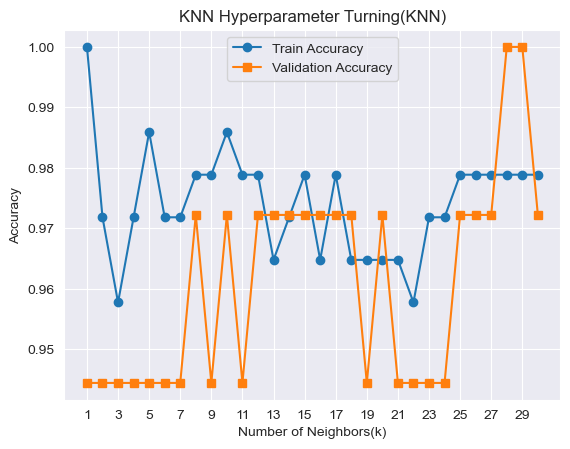

In [10]:
import matplotlib.pyplot as plt 
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

k_value = list(range(1, 31))
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(knn.score(X_train_scaled, y_train))
    val_accuracies.append(knn.score(X_test_scaled, y_test))

combination = pd.DataFrame({
    'Train Accuracies': train_accuracies,
    'Value Accuracies': train_accuracies
})
print(combination)

sns.set_style("darkgrid")
plt.plot(k_value, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(k_value, val_accuracies, label="Validation Accuracy", marker="s")
plt.xlabel("Number of Neighbors(k)")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Turning(KNN)")
plt.xticks(range(1,31,2))
plt.legend()
plt.show()